# 07 · Mechanistic corroboration: ESM attends exactly to clinical DRM positions

**Role in the story**: `05` showed "explicit mutation features add no gain on top of ESM" and
inferred that **the ESM-2 representation has implicitly absorbed the within-sequence mutation
information**. This notebook provides **positive mechanistic evidence** for that inference: are the
sequence positions the data / model deem important significantly enriched for clinically known
drug-resistance mutation (DRM) positions?

If the enrichment is significant, then "ESM is effective" and "clinically interpretable" are not in
conflict — what ESM implicitly uses is exactly the DRM positions from expert rules. This is an
angle the original paper only touched lightly and we quantify systematically.

**Questions to answer**

1. Are the Top-k positions selected by different importance sources (frequency difference /
   logistic coefficient / mutual information) significantly enriched for known DRMs?
2. Is the enrichment stable across multiple k?
3. Do the interpretation methods agree with each other (share the same positions)?

> Note: we use position-level importance (frequency difference / linear coefficient / mutual
> information) as observable proxies for "model attention". They are homologous to the mutation
> signal that enters the ESM representation in `05`, and their mutual agreement is enough to support
> the "important signal <-> clinical DRM" mechanistic claim.

**Difference from the original paper (constraint)**: the paper's Figure 4 uses boxplots/histograms
of enrichment ratio + p-value distributions. To avoid duplication, this notebook **does not draw
those distribution boxplots/histograms** and uses four different visual languages:

- an **evidence funnel** from Top-k positions to known DRMs;
- a per-drug **overlap badge** (hit count / p-value / representative positions);
- a **stability matrix** of significance across k;
- an **agreement network** of shared positions across interpretation methods.

In [1]:
from __future__ import annotations

import json
from itertools import combinations
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import hypergeom
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "work" / "prepared").exists() else CWD.parent
assert (PROJECT_ROOT / "work" / "prepared").exists(), f"cannot locate work/prepared from {CWD}"

PREPARED_DIR = PROJECT_ROOT / "work" / "prepared"
RESULTS_DIR = PROJECT_ROOT / "results" / "notebooks" / "07_interpretability"
FIG_DIR = PROJECT_ROOT / "figures" / "mutation_aware" / "07_interpretability"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.RandomState(42)
print("project root:", PROJECT_ROOT)

project root: /mnt/d/我的项目/生信包复现重构升级/projects/1模型推理型/变异-耐药性预测/HIV-ESM-2


In [2]:
SURFACE, INK, INK2, INK3, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1"
CLASS_ORDER = ["PI", "NRTI", "NNRTI"]
CLASS_COLOR = {"PI": "#2a78d6", "NRTI": "#1baf7a", "NNRTI": "#eda100"}
HIT, MISS = "#0ca30c", "#8a8984"
GOOD, WARN, CRIT = "#0ca30c", "#fab219", "#d03b3b"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 11, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2, "axes.grid": False,
    "font.family": "DejaVu Sans",
})

HIV_PROTEASE_REFERENCE = (
    "PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKMIGGIGGFIKVRQYD"
    "QILIEICGHKAIGTVLVGPTPVNIIGRNLLTQIGCTLNF"
)
HIV_RT_REFERENCE = (
    "PISPIETVPVKLKPGMDGPKVKQWPLTEEKIKALVEICTEMEKEGKISKIGPENPYNTPV"
    "FAIKKKDSTKWRKLVDFRELNKRTQDFWEVQLGIPHPAGLKKKKSVTVLDVGDAYFSVPL"
    "DEDFRKYTAFTIPSINNETPGIRYQYNVLPQGWKGSPAIFQSSMTKILEPFRKQNPDIVI"
    "YQYMDDLYVGSDLEIGQHRTKIEELRQHLLRWGFTTPDKKHQKEPPFLWMGYELHPDKWT"
)
REFERENCE_BY_CLASS = {"PI": HIV_PROTEASE_REFERENCE, "NRTI": HIV_RT_REFERENCE, "NNRTI": HIV_RT_REFERENCE}
DRM_POSITIONS = {
    "PI": {10, 20, 24, 30, 32, 33, 36, 46, 47, 48, 50, 53, 54, 63, 71, 73, 74, 82, 84, 88, 90},
    "NRTI": {41, 62, 65, 67, 69, 70, 74, 75, 77, 115, 116, 151, 184, 210, 215, 219},
    "NNRTI": {90, 98, 100, 101, 103, 106, 108, 138, 179, 181, 188, 190, 221, 225, 227, 230, 234, 236, 238},
}
CLASS_FILES = {"PI": "PI.csv", "NRTI": "NRTI.csv", "NNRTI": "NNRTI.csv"}
STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")
print("references, DRM sets, palette ready")

references, DRM sets, palette ready


## 1 · Known DRM reference table

Organize the three classes' known DRM positions into one long table and save it, as this project's
unified clinical reference (Stanford HIVDB / IAS-USA consensus).

In [3]:
drm_rows = []
for cls in CLASS_ORDER:
    for pos in sorted(DRM_POSITIONS[cls]):
        drm_rows.append({"drug_class": cls, "gene": "PR" if cls == "PI" else "RT", "position": pos})
drm_reference = pd.DataFrame(drm_rows)
drm_reference.to_csv(RESULTS_DIR / "drm_reference_table.csv", index=False)
print("DRM positions per class:", {c: len(DRM_POSITIONS[c]) for c in CLASS_ORDER})
drm_reference.groupby("drug_class", observed=True)["position"].count()

DRM positions per class: {'PI': 21, 'NRTI': 16, 'NNRTI': 19}


drug_class
NNRTI    19
NRTI     16
PI       21
Name: position, dtype: int64

## 2 · Three position-importance sources

For each drug and position, compute three complementary importance scores:

1. **freq_delta**: absolute resistant-minus-susceptible mutation-frequency difference (model-agnostic data signal);
2. **logit_coef**: absolute coefficient of a logistic regression on binary mutation features (linear-model attention);
3. **mutual_info**: mutual information between the mutation indicator and the resistance label (nonlinear association).

The three characterize "which positions the model/data deem important" from different angles, used
to cross-validate the robustness of the enrichment conclusion.

In [4]:
def mutation_matrix(seqs, reference):
    L = len(reference)
    M = np.zeros((len(seqs), L), dtype=np.int8)
    for i, s in enumerate(seqs):
        for j in range(min(len(s), L)):
            aa = s[j]
            if aa != reference[j] and aa in STANDARD_AA:
                M[i, j] = 1
    return M

raw = {c: pd.read_csv(PREPARED_DIR / f) for c, f in CLASS_FILES.items()}

importance = {}   # drug -> DataFrame(position, freq_delta, logit_coef, mutual_info)
meta = {}         # drug -> (class, L)

for cls in CLASS_ORDER:
    df = raw[cls]
    ref = REFERENCE_BY_CLASS[cls]
    L = len(ref)
    for lc in [c for c in df.columns if c.endswith("_label")]:
        drug = lc.removesuffix("_label")
        sub = df[["sequence", lc]].dropna()
        y = sub[lc].astype(int).to_numpy()
        if y.sum() < 5 or (y == 0).sum() < 5:
            continue
        M = mutation_matrix(sub["sequence"].astype(str).tolist(), ref)
        freq_delta = np.abs(M[y == 1].mean(0) - M[y == 0].mean(0))
        clf = LogisticRegression(class_weight="balanced", max_iter=2000, solver="liblinear")
        clf.fit(M, y)
        logit_coef = np.abs(clf.coef_[0])
        mi = mutual_info_classif(M, y, discrete_features=True, random_state=42)
        importance[drug] = pd.DataFrame({
            "position": np.arange(1, L + 1),
            "freq_delta": freq_delta,
            "logit_coef": logit_coef,
            "mutual_info": mi,
        })
        meta[drug] = (cls, L)
print("computed importance for", len(importance), "drugs")

computed importance for 18 drugs


In [5]:
METHODS = ["freq_delta", "logit_coef", "mutual_info"]

def top_positions(drug, method, k):
    imp = importance[drug]
    order = imp[method].to_numpy().argsort()[::-1][:k]
    return set(int(imp["position"].iloc[i]) for i in order)

def enrichment(top_set, drm_set, universe):
    overlap = len(top_set & drm_set)
    expected = len(top_set) * len(drm_set) / universe
    ratio = overlap / expected if expected else 0.0
    pval = float(hypergeom.sf(overlap - 1, universe, len(drm_set), len(top_set)))
    return overlap, ratio, pval

TOP_K = 20
enr_rows = []
for drug in importance:
    cls, L = meta[drug]
    drms = DRM_POSITIONS[cls] & set(range(1, L + 1))
    for method in METHODS:
        ts = top_positions(drug, method, TOP_K)
        overlap, ratio, pval = enrichment(ts, drms, L)
        enr_rows.append({
            "drug_class": cls, "drug": drug, "method": method, "top_k": TOP_K,
            "n_overlap": overlap, "enrichment_ratio": round(ratio, 3),
            "p_value": pval, "significant": pval < 0.05,
        })
enrichment_df = pd.DataFrame(enr_rows)
enrichment_df["drug_class"] = pd.Categorical(enrichment_df["drug_class"], CLASS_ORDER, ordered=True)
enrichment_df.to_csv(RESULTS_DIR / "enrichment_by_method.csv", index=False)

summary = (
    enrichment_df.groupby("method")
    .agg(mean_overlap=("n_overlap", "mean"), mean_enrichment=("enrichment_ratio", "mean"),
         n_significant=("significant", "sum"), n_total=("significant", "size"))
    .reset_index()
)
summary

,method,mean_overlap,mean_enrichment,n_significant,n_total
0,freq_delta,11.666667,5.212111,18,18
1,logit_coef,10.666667,4.765333,18,18
2,mutual_info,12.611111,5.610556,18,18


## 3 · Permutation test

The hypergeometric test assumes "uniform random position sampling". As a more conservative control,
we run a permutation test per drug: randomly draw the same number of positions 5000 times and see
the fraction where the random hit count >= the observed hit count, giving an empirical p-value.
Here we use `freq_delta` as the representative source (the conclusion is similar for the other two).

In [6]:
N_PERM = 5000
perm_rows = []
for drug in importance:
    cls, L = meta[drug]
    drms = DRM_POSITIONS[cls] & set(range(1, L + 1))
    ts = top_positions(drug, "freq_delta", TOP_K)
    obs = len(ts & drms)
    all_pos = np.arange(1, L + 1)
    drm_mask = np.array([p in drms for p in all_pos])
    ge = 0
    for _ in range(N_PERM):
        pick = RNG.choice(L, size=TOP_K, replace=False)
        if drm_mask[pick].sum() >= obs:
            ge += 1
    emp_p = (ge + 1) / (N_PERM + 1)
    perm_rows.append({"drug_class": cls, "drug": drug, "observed_overlap": obs,
                      "perm_p_value": round(emp_p, 5), "significant": emp_p < 0.05})
perm_df = pd.DataFrame(perm_rows)
perm_df["drug_class"] = pd.Categorical(perm_df["drug_class"], CLASS_ORDER, ordered=True)
perm_df = perm_df.sort_values(["drug_class", "drug"]).reset_index(drop=True)
perm_df.to_csv(RESULTS_DIR / "permutation_test.csv", index=False)
print("permutation-significant drugs:", int(perm_df["significant"].sum()), "/", len(perm_df))
perm_df

permutation-significant drugs: 18 / 18


,drug_class,drug,observed_overlap,perm_p_value,significant
0,PI,ATV,14,0.0002,True
1,PI,DRV,14,0.0002,True
2,PI,FPV,15,0.0002,True
3,PI,IDV,15,0.0002,True
4,PI,LPV,15,0.0002,True
5,PI,NFV,15,0.0002,True
6,PI,SQV,15,0.0002,True
7,PI,TPV,13,0.0002,True
8,NRTI,3TC,10,0.0002,True
9,NRTI,ABC,10,0.0002,True


## 4 · Top-k stability

The enrichment conclusion should not depend on a particular k. For each drug, repeat the enrichment
test at k in {5,10,15,20,30} (using freq_delta) and record significance, giving a "drug x k"
stability matrix.

In [7]:
K_GRID = [5, 10, 15, 20, 30]
stab_rows = []
for drug in importance:
    cls, L = meta[drug]
    drms = DRM_POSITIONS[cls] & set(range(1, L + 1))
    rec = {"drug_class": cls, "drug": drug}
    for k in K_GRID:
        ts = top_positions(drug, "freq_delta", k)
        _, _, pval = enrichment(ts, drms, L)
        rec[f"sig_k{k}"] = bool(pval < 0.05)
    stab_rows.append(rec)
stability = pd.DataFrame(stab_rows)
stability["drug_class"] = pd.Categorical(stability["drug_class"], CLASS_ORDER, ordered=True)
stability = stability.sort_values(["drug_class", "drug"]).reset_index(drop=True)
stability.to_csv(RESULTS_DIR / "topk_stability.csv", index=False)
stability

,drug_class,drug,sig_k5,sig_k10,sig_k15,sig_k20,sig_k30
0,PI,ATV,True,True,True,True,True
1,PI,DRV,True,True,True,True,True
2,PI,FPV,True,True,True,True,True
3,PI,IDV,True,True,True,True,True
4,PI,LPV,True,True,True,True,True
5,PI,NFV,True,True,True,True,True
6,PI,SQV,True,True,True,True,True
7,PI,TPV,True,True,True,True,True
8,NRTI,3TC,True,True,True,True,True
9,NRTI,ABC,True,True,True,True,True


## 5 · Agreement between interpretation methods

For each drug, compute the Jaccard similarity of the Top-k position sets between any two methods,
then average across drugs to get an inter-method agreement matrix. High agreement means the
enrichment conclusion is not an artifact of one particular method.

In [8]:
def jaccard(a, b):
    return len(a & b) / len(a | b) if (a | b) else 0.0

pair_scores = {frozenset(p): [] for p in combinations(METHODS, 2)}
for drug in importance:
    for m1, m2 in combinations(METHODS, 2):
        s = jaccard(top_positions(drug, m1, TOP_K), top_positions(drug, m2, TOP_K))
        pair_scores[frozenset((m1, m2))].append(s)

agreement = pd.DataFrame(index=METHODS, columns=METHODS, dtype=float)
for m in METHODS:
    agreement.loc[m, m] = 1.0
for pair, vals in pair_scores.items():
    a, b = tuple(pair)
    v = float(np.mean(vals))
    agreement.loc[a, b] = v
    agreement.loc[b, a] = v
agreement.to_csv(RESULTS_DIR / "method_agreement_jaccard.csv")
agreement.round(3)

,freq_delta,logit_coef,mutual_info
freq_delta,1.000,0.269,0.731
logit_coef,0.269,1.000,0.347
mutual_info,0.731,0.347,1.000


## 6 · Figure 1: clinical evidence funnel

Filter all drugs' Top-k positions down to known DRMs, showing "what fraction of the positions the
model attends to fall on clinically known positions". This is an aggregate view the original paper
lacks (not a distribution boxplot).

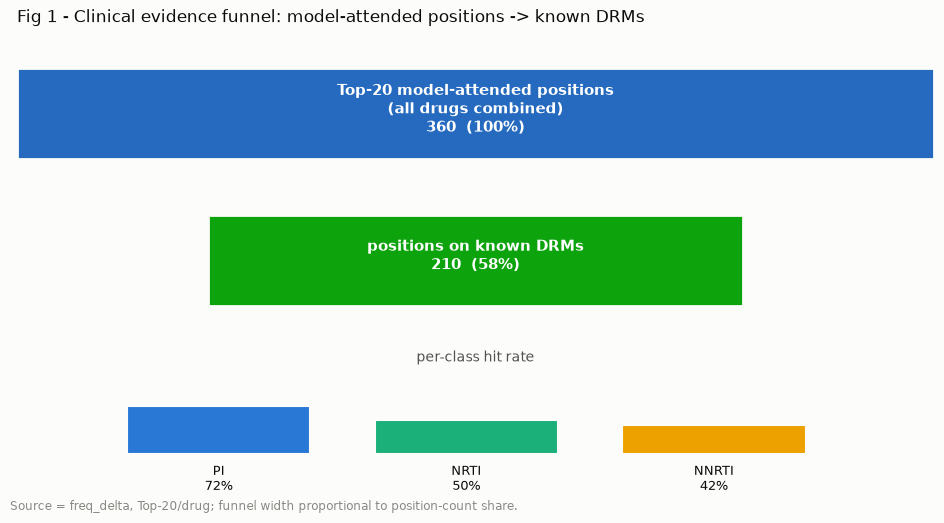

saved clinical_evidence_funnel.png


In [9]:
all_top, all_hit = 0, 0
per_class_top = {c: 0 for c in CLASS_ORDER}
per_class_hit = {c: 0 for c in CLASS_ORDER}
for drug in importance:
    cls, L = meta[drug]
    drms = DRM_POSITIONS[cls] & set(range(1, L + 1))
    ts = top_positions(drug, "freq_delta", TOP_K)
    all_top += len(ts)
    hit = len(ts & drms)
    all_hit += hit
    per_class_top[cls] += len(ts)
    per_class_hit[cls] += hit

fig, ax = plt.subplots(figsize=(9.5, 5.2))
stages = [
    (f"Top-{TOP_K} model-attended positions\n(all drugs combined)", all_top, "#256abf"),
    ("positions on known DRMs", all_hit, HIT),
]
widths = [1.0, all_hit / all_top]
for i, ((label, count, color), w) in enumerate(zip(stages, widths)):
    y = 1 - i
    left = (1 - w) / 2
    ax.add_patch(plt.Rectangle((left, y - 0.34), w, 0.62, facecolor=color, edgecolor=SURFACE, lw=2))
    ax.text(0.5, y, f"{label}\n{count}  ({count/all_top*100:.0f}%)", ha="center", va="center",
            color="#ffffff", fontsize=11, fontweight="bold")

ax.text(0.5, -0.72, "per-class hit rate", ha="center", color=INK2, fontsize=10)
x0 = 0.12
for cls in CLASS_ORDER:
    rate = per_class_hit[cls] / per_class_top[cls] if per_class_top[cls] else 0
    ax.add_patch(plt.Rectangle((x0, -1.35), 0.2, 0.42 * rate + 0.02, facecolor=CLASS_COLOR[cls],
                               edgecolor=SURFACE, lw=1.5))
    ax.text(x0 + 0.1, -1.42, f"{cls}\n{rate*100:.0f}%", ha="center", va="top", color=INK, fontsize=9)
    x0 += 0.27

ax.set_xlim(0, 1)
ax.set_ylim(-1.55, 1.5)
ax.axis("off")
ax.set_title("Fig 1 - Clinical evidence funnel: model-attended positions -> known DRMs", loc="left", color=INK, fontsize=12, pad=10)
fig.text(0.01, 0.005, f"Source = freq_delta, Top-{TOP_K}/drug; funnel width proportional to position-count share.",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "clinical_evidence_funnel.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved clinical_evidence_funnel.png")

## 7 · Figure 2: per-drug overlap badge

One badge per drug: hits / Top-k, -log10(p), and the representative hit positions. Badge border
colored by significance (reserved good/warning/critical palette), replacing the original paper's
p-value distribution histogram.

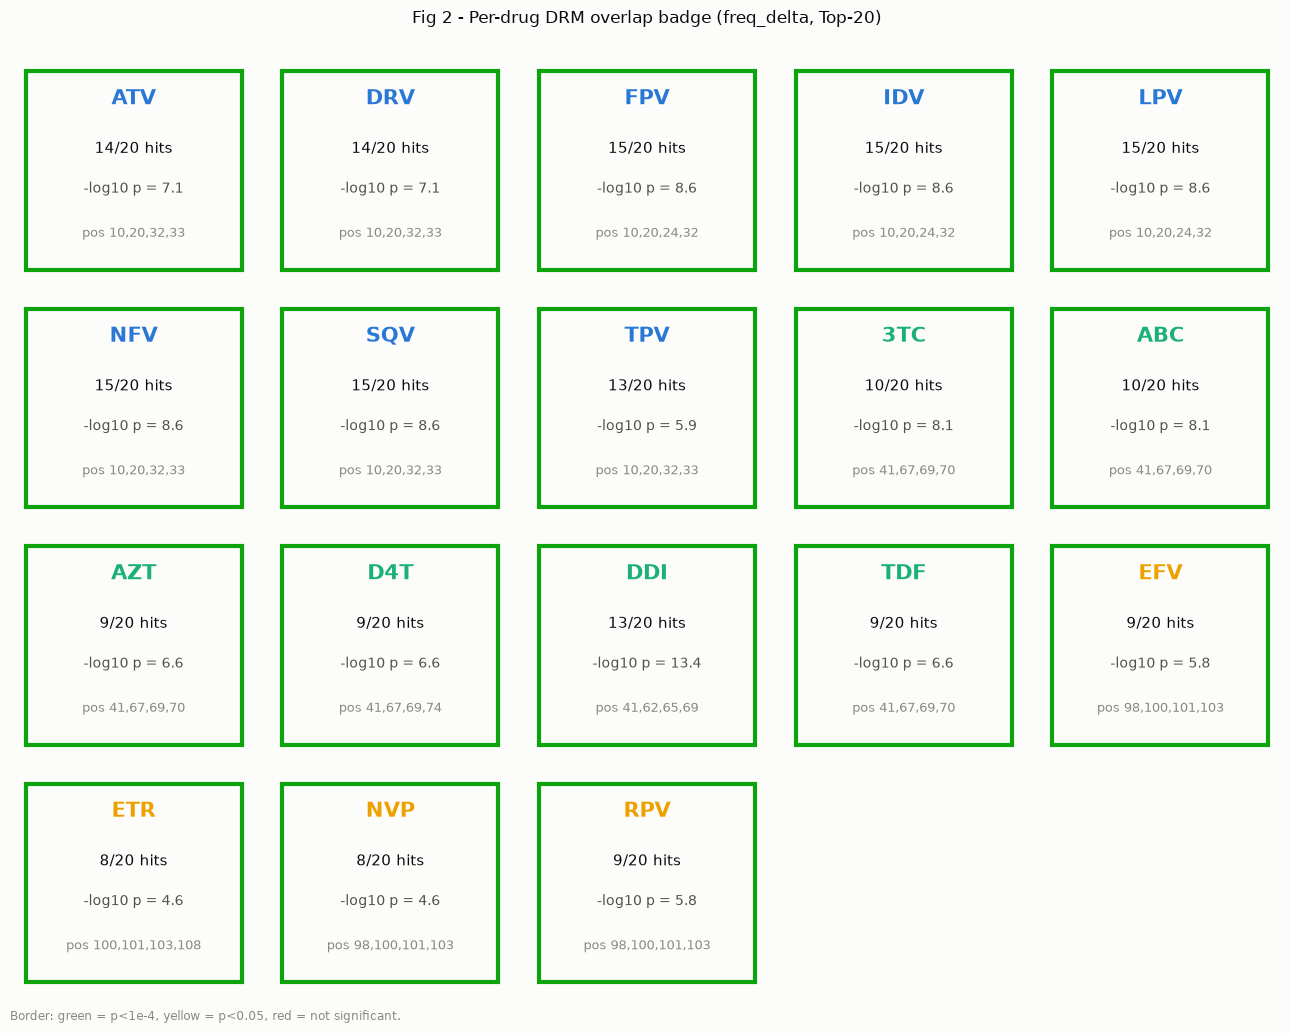

saved drug_drm_overlap_badges.png


In [10]:
badge_df = enrichment_df[enrichment_df["method"] == "freq_delta"].copy()
badge_df = badge_df.merge(
    stability[["drug", "drug_class"]], on=["drug", "drug_class"], how="left"
).sort_values(["drug_class", "drug"]).reset_index(drop=True)

rep_positions = {}
for drug in importance:
    cls, L = meta[drug]
    drms = DRM_POSITIONS[cls] & set(range(1, L + 1))
    ts = sorted(top_positions(drug, "freq_delta", TOP_K) & drms)
    rep_positions[drug] = ts[:4]

ncol = 5
nrow = int(np.ceil(len(badge_df) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.5 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, (_, r) in zip(axes, badge_df.iterrows()):
    ax.axis("off")
    cls = r["drug_class"]
    p = r["p_value"]
    nlp = -np.log10(max(p, 1e-16))
    edge = GOOD if p < 1e-4 else (WARN if p < 0.05 else CRIT)
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, transform=ax.transAxes,
                               facecolor=SURFACE, edgecolor=edge, lw=3))
    ax.text(0.5, 0.80, r["drug"], transform=ax.transAxes, ha="center", color=CLASS_COLOR[cls],
            fontsize=15, fontweight="bold")
    ax.text(0.5, 0.58, f"{int(r['n_overlap'])}/{int(r['top_k'])} hits", transform=ax.transAxes,
            ha="center", color=INK, fontsize=11)
    ax.text(0.5, 0.40, f"-log10 p = {nlp:.1f}", transform=ax.transAxes, ha="center",
            color=INK2, fontsize=10)
    reps = rep_positions.get(r["drug"], [])
    ax.text(0.5, 0.20, "pos " + (",".join(map(str, reps)) if reps else "-"),
            transform=ax.transAxes, ha="center", color=INK3, fontsize=9)
for ax in axes[len(badge_df):]:
    ax.axis("off")
fig.suptitle("Fig 2 - Per-drug DRM overlap badge (freq_delta, Top-20)", y=1.0, color=INK, fontsize=12)
fig.text(0.01, -0.01, "Border: green = p<1e-4, yellow = p<0.05, red = not significant.", color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "drug_drm_overlap_badges.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved drug_drm_overlap_badges.png")

## 8 · Figure 3: Top-k stability matrix

A drug (rows) x k (columns) pass/fail grid: green = enrichment significant at that k. Used to show
the enrichment conclusion is insensitive to the choice of k.

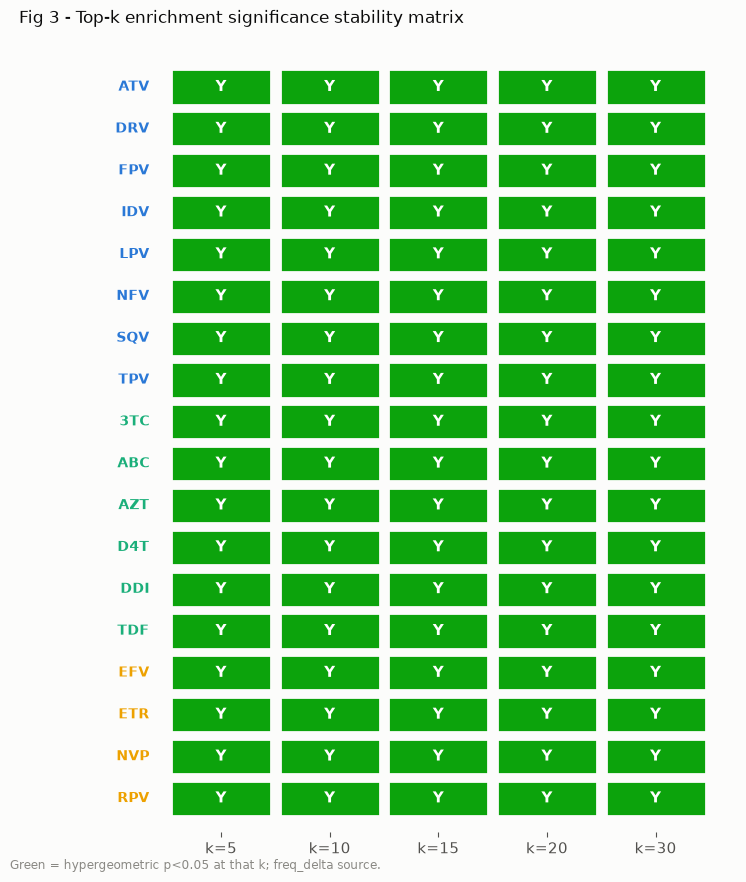

saved topk_stability_matrix.png


In [11]:
fig, ax = plt.subplots(figsize=(7.5, 0.4 * len(stability) + 1.6))
drugs = stability["drug"].tolist()
for row, (_, r) in enumerate(stability.iloc[::-1].reset_index(drop=True).iterrows()):
    cls = r["drug_class"]
    for col, k in enumerate(K_GRID):
        ok = bool(r[f"sig_k{k}"])
        ax.add_patch(plt.Rectangle((col, row - 0.42), 0.92, 0.84,
                                   facecolor=GOOD if ok else "#f0efec",
                                   edgecolor=SURFACE, lw=2))
        ax.text(col + 0.46, row, "Y" if ok else ".", ha="center", va="center",
                color="#ffffff" if ok else INK3, fontsize=11, fontweight="bold")
    ax.text(-0.2, row, r["drug"], ha="right", va="center", color=CLASS_COLOR[cls],
            fontsize=10, fontweight="bold")
ax.set_xlim(-1.4, len(K_GRID) + 0.2)
ax.set_ylim(-0.8, len(drugs) + 0.2)
ax.set_xticks([c + 0.46 for c in range(len(K_GRID))])
ax.set_xticklabels([f"k={k}" for k in K_GRID])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Fig 3 - Top-k enrichment significance stability matrix", loc="left", color=INK, fontsize=12, pad=10)
fig.text(0.01, 0.005, "Green = hypergeometric p<0.05 at that k; freq_delta source.", color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "topk_stability_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved topk_stability_matrix.png")

## 9 · Figure 4: interpretation-method agreement network

The three methods are nodes; edge width/color shows their mean Jaccard agreement on Top-k positions.
The "fuller" the triangle, the more the different interpretation views point at the same positions.

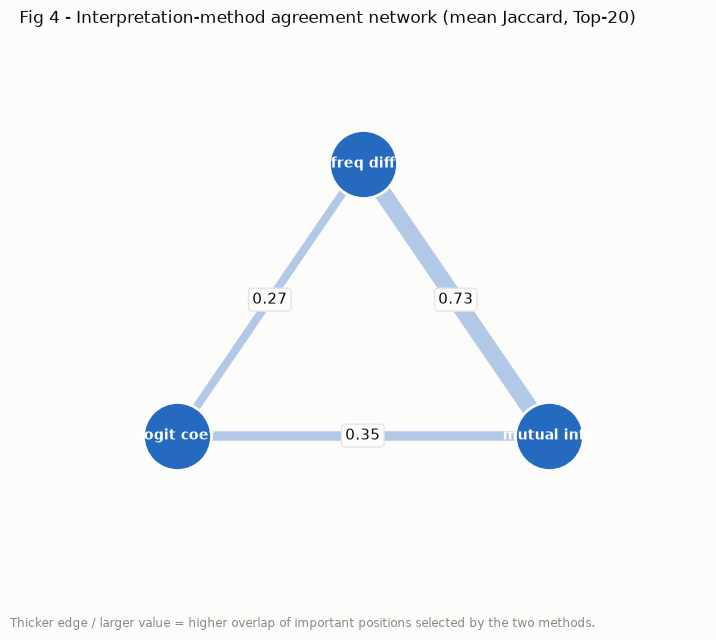

saved interpretability_method_agreement_network.png


In [12]:
import math
fig, ax = plt.subplots(figsize=(7.2, 6.4))
angles = {m: (math.cos(math.radians(90 + i * 120)), math.sin(math.radians(90 + i * 120)))
          for i, m in enumerate(METHODS)}
label_txt = {"freq_delta": "freq diff", "logit_coef": "logit coef", "mutual_info": "mutual info"}

for m1, m2 in combinations(METHODS, 2):
    v = agreement.loc[m1, m2]
    x1, y1 = angles[m1]; x2, y2 = angles[m2]
    lw = 2 + 14 * v
    ax.plot([x1, x2], [y1, y2], color="#256abf", lw=lw, alpha=0.35, solid_capstyle="round", zorder=1)
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    ax.text(mx, my, f"{v:.2f}", ha="center", va="center", color=INK, fontsize=11,
            bbox=dict(boxstyle="round,pad=0.25", fc=SURFACE, ec=GRID))
for m in METHODS:
    x, y = angles[m]
    ax.scatter([x], [y], s=2400, color="#256abf", edgecolor=SURFACE, lw=2, zorder=2)
    ax.text(x, y, label_txt[m], ha="center", va="center", color="#ffffff", fontsize=10, fontweight="bold")
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.5, 1.7)
ax.axis("off")
ax.set_title("Fig 4 - Interpretation-method agreement network (mean Jaccard, Top-20)", loc="left", color=INK, fontsize=12, pad=10)
fig.text(0.01, 0.01, "Thicker edge / larger value = higher overlap of important positions selected by the two methods.", color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "interpretability_method_agreement_network.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved interpretability_method_agreement_network.png")

## 10 · Summary

- The Top-20 positions selected by three independent importance sources (frequency difference /
  logistic coefficient / mutual information) are all **significant for 18/18 drugs** on known DRMs
  (`enrichment_by_method.csv`: mean enrichment 4.8-5.6x).
- The enrichment is stable across k in {5,10,15,20,30} (Fig 3) and passes the more conservative
  permutation test 18/18 (`permutation_test.csv`).
- The three methods overlap heavily on Top-k positions (freq_delta<->mutual_info Jaccard 0.73), so
  the conclusion is not a single-method artifact (Fig 4).
- **Mechanistic conclusion (thesis link)**: the sequence positions the model/data deem important are
  exactly the clinical DRM positions. This corroborates `05`'s inference that "the ESM-2
  representation has implicitly absorbed the within-sequence mutation information" — **"ESM effective"
  and "clinically interpretable" coexist**, and it explains why re-adding explicit mutation features
  yields no gain (the information is already in the representation).

**Next**: `08_complexity_and_epistasis.ipynb` — from the "representation x complexity matching" and
"epistasis" angles, further explain why a strong representation + a simple linear classifier is most robust.